In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/featured.csv')

with open('../models/rf_classifier.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('../models/xgb_classifier.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open('../models/gbm_regressor.pkl', 'rb') as f:
    gbm_model = pickle.load(f)

print("✅ All loaded!")

✅ All loaded!


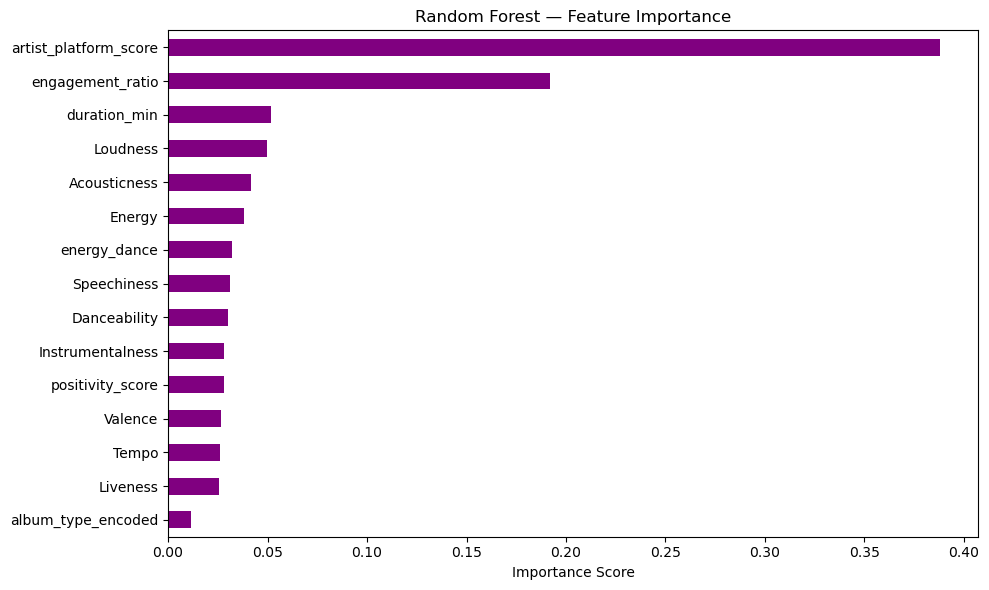

✅ Saved!


In [3]:
# Classification models were trained WITHOUT gap_score (Phase 5)
clf_features = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
    'Tempo', 'duration_min', 'engagement_ratio',
    'energy_dance', 'positivity_score',
    'artist_platform_score', 'album_type_encoded'
]

# Regression model was trained WITH gap_score (Phase 6)
reg_features = clf_features + ['gap_score']

# Random Forest importance
rf_importance = pd.Series(rf_model.feature_importances_, index=clf_features)
rf_importance = rf_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
rf_importance.plot(kind='barh', color='purple')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/figures/rf_feature_importance.png')
plt.show()
print("✅ Saved!")

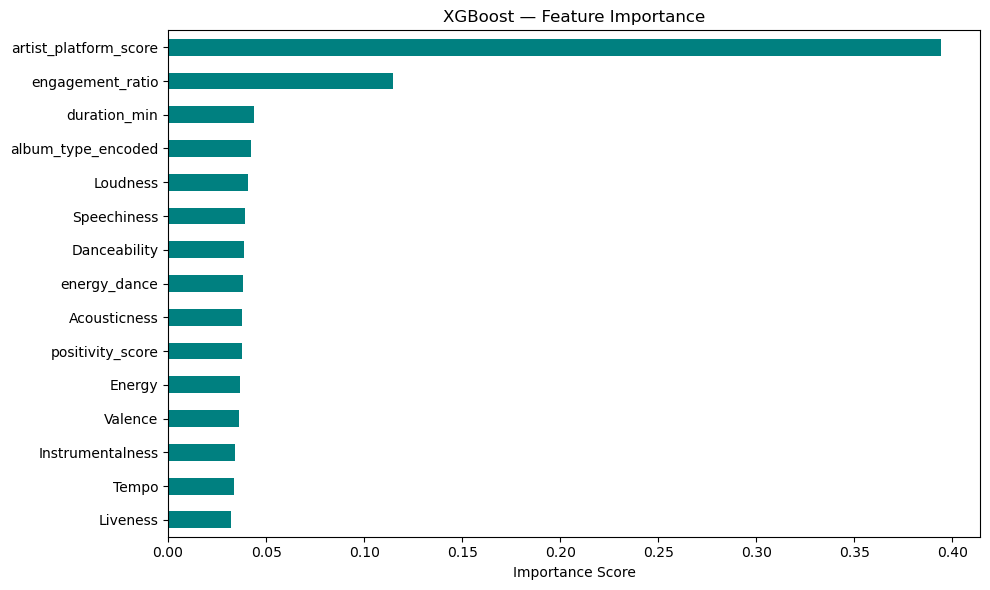

✅ Saved!


In [4]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index=clf_features)
xgb_importance = xgb_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
xgb_importance.plot(kind='barh', color='teal')
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_feature_importance.png')
plt.show()
print("✅ Saved!")

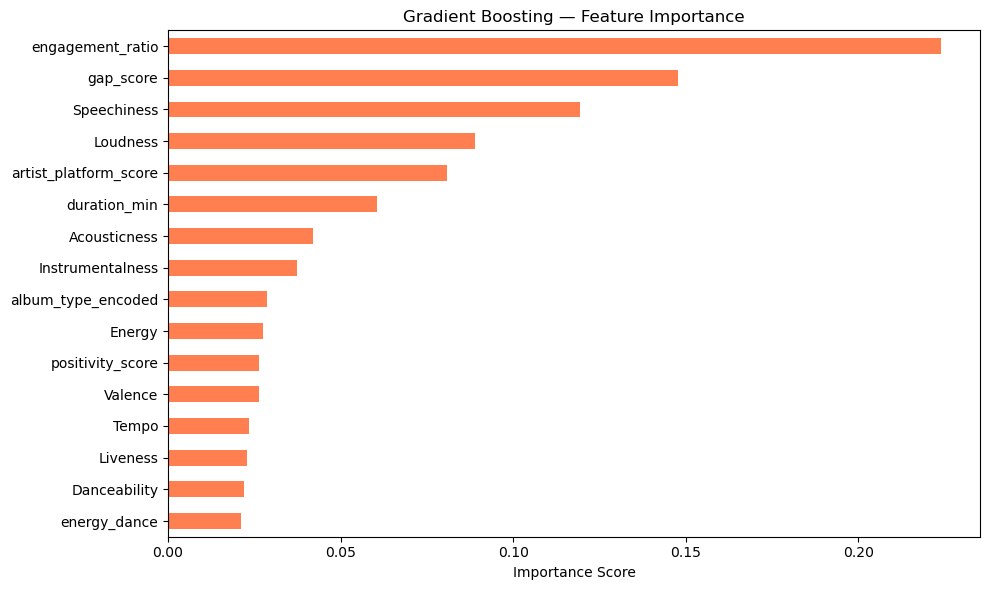

✅ Saved!


In [5]:
gbm_importance = pd.Series(gbm_model.feature_importances_, index=reg_features)
gbm_importance = gbm_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
gbm_importance.plot(kind='barh', color='coral')
plt.title('Gradient Boosting — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/figures/gbm_feature_importance.png')
plt.show()
print("✅ Saved!")

<Figure size 1200x600 with 0 Axes>

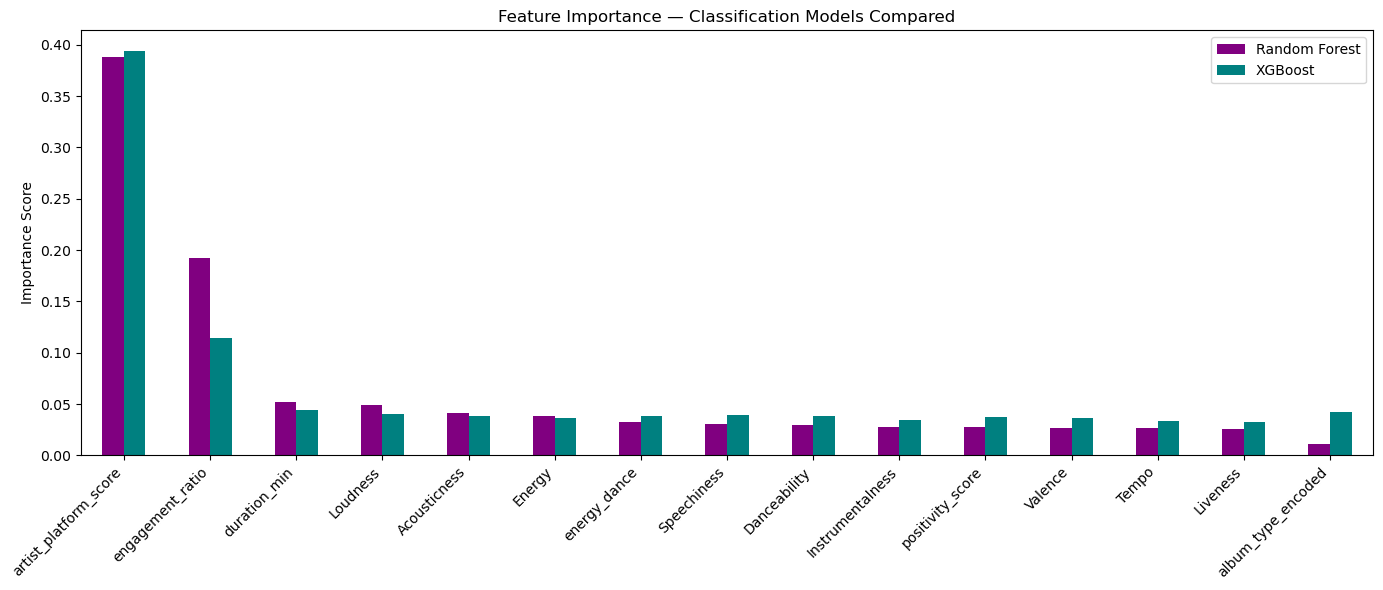

✅ Saved!


In [6]:
importance_df = pd.DataFrame({
    'Random Forest'     : rf_model.feature_importances_,
    'XGBoost'           : xgb_model.feature_importances_,
}, index=clf_features)

importance_df = importance_df.sort_values('Random Forest', ascending=False)

plt.figure(figsize=(12, 6))
importance_df.plot(kind='bar', figsize=(14, 6), color=['purple','teal'])
plt.title('Feature Importance — Classification Models Compared')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/all_models_feature_importance.png')
plt.show()
print("✅ Saved!")

In [7]:
# Top 3 features per model
print("── Top 5 Features by Model ─────────────────────")
print(f"\nRandom Forest:")
print(rf_importance.sort_values(ascending=False).head(5))

print(f"\nXGBoost:")
print(xgb_importance.sort_values(ascending=False).head(5))

print(f"\nGradient Boosting:")
print(gbm_importance.sort_values(ascending=False).head(5))

── Top 5 Features by Model ─────────────────────

Random Forest:
artist_platform_score    0.387763
engagement_ratio         0.191968
duration_min             0.051631
Loudness                 0.049497
Acousticness             0.041744
dtype: float64

XGBoost:
artist_platform_score    0.394397
engagement_ratio         0.114774
duration_min             0.043911
album_type_encoded       0.042384
Loudness                 0.040626
dtype: float32

Gradient Boosting:
engagement_ratio         0.224105
gap_score                0.147913
Speechiness              0.119502
Loudness                 0.088973
artist_platform_score    0.080875
dtype: float64


In [8]:
# Which artists are Spotify artists vs YouTube artists?
artist_platform = df.groupby('Artist').agg(
    avg_gap_score    = ('gap_score', 'mean'),
    total_streams    = ('Stream', 'sum'),
    total_views      = ('Views', 'sum'),
    song_count       = ('Track', 'count')
).reset_index()

# Label each artist
artist_platform['platform_identity'] = artist_platform['avg_gap_score'].apply(
    lambda x: 'Spotify Artist' if x > 0.5
              else ('YouTube Artist' if x < -0.5
              else 'Cross-platform Artist')
)

print("✅ Artist Platform Identity:")
print(artist_platform['platform_identity'].value_counts())
print("\nTop 10 Spotify Artists:")
print(artist_platform[artist_platform['platform_identity']=='Spotify Artist']
      .sort_values('total_streams', ascending=False).head(10)[['Artist','avg_gap_score','song_count']])
print("\nTop 10 YouTube Artists:")
print(artist_platform[artist_platform['platform_identity']=='YouTube Artist']
      .sort_values('total_views', ascending=False).head(10)[['Artist','avg_gap_score','song_count']])

# Save
artist_platform.to_csv('../data/outputs/artist_platform_identity.csv', index=False)
print("\n✅ Saved to data/outputs/artist_platform_identity.csv")

✅ Artist Platform Identity:
platform_identity
Spotify Artist           1582
Cross-platform Artist     366
YouTube Artist             93
Name: count, dtype: int64

Top 10 Spotify Artists:
               Artist  avg_gap_score  song_count
1471      Post Malone       1.643916          10
516        Ed Sheeran       0.587510          10
497          Dua Lipa       0.695703          10
1966     XXXTENTACION       3.160276          10
1830       The Weeknd       1.725646          10
909     Justin Bieber       1.325183          10
765   Imagine Dragons       0.517164          10
963            Khalid       1.544447          10
263        Bruno Mars       0.547109          10
125     Ariana Grande       1.006769          10

Top 10 YouTube Artists:
                       Artist  avg_gap_score  song_count
368                 CoComelon      -2.852244          10
1164  Macklemore & Ryan Lewis      -1.710181          10
591             Fifth Harmony      -0.755145          10
1411                 

In [9]:
print("═" * 55)
print("   KEY INSIGHTS — Music Popularity Intelligence")
print("═" * 55)

top_rf  = rf_importance.sort_values(ascending=False).index[0]
top_xgb = xgb_importance.sort_values(ascending=False).index[0]
top_gbm = gbm_importance.sort_values(ascending=False).index[0]

print(f"""
1. Most important feature (RF)  → {top_rf}
2. Most important feature (XGB) → {top_xgb}
3. Most important feature (GBM) → {top_gbm}

4. Gradient Boosting beats Linear Regression
   RMSE: 1.41 vs 1.55  |  R²: 0.30 vs 0.15

5. Artist platform identity is a strong predictor
   — Artists consistently perform better on one platform

6. Gap Score = most unique feature in this project
   — Separates this from every basic music ML project
""")
print("═" * 55)

═══════════════════════════════════════════════════════
   KEY INSIGHTS — Music Popularity Intelligence
═══════════════════════════════════════════════════════

1. Most important feature (RF)  → artist_platform_score
2. Most important feature (XGB) → artist_platform_score
3. Most important feature (GBM) → engagement_ratio

4. Gradient Boosting beats Linear Regression
   RMSE: 1.41 vs 1.55  |  R²: 0.30 vs 0.15

5. Artist platform identity is a strong predictor
   — Artists consistently perform better on one platform

6. Gap Score = most unique feature in this project
   — Separates this from every basic music ML project

═══════════════════════════════════════════════════════
